---
tags: [tutorial, resource-estimation]
---

# リソース推定

量子カーネルを実機で実行する前に、必要なリソース（量子ビット数、ゲート数等）を把握しておきたい場合や、そもそも定義した量子カーネルを実行するために必要なリソースを知りたい場合があります。Qamomileの`estimate_resources()`は**量子カーネルを実行せずに**リソース推定が可能です。具体的な（パラメータ固定の）量子カーネルにも、シンボリック（パラメータ付き）な量子カーネルにも対応しています。

この章では以下を扱います：

- 固定量子カーネルの基本的なリソース推定
- パラメータ付き量子カーネルのシンボリックなリソース推定
- `ResourceEstimate`フィールドリファレンス
- `.substitute()`によるスケーリング分析
- ショアのアルゴリズムの位数探索への応用

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import qamomile.circuit as qmc

## 固定量子カーネルのリソース推定

パラメータを持たない量子カーネルに対しては、`estimate_resources()`は具体的な数値を返します。

In [3]:
@qmc.qkernel
def fixed_circuit() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")

    q[0] = qmc.h(q[0])
    q[0], q[1] = qmc.cx(q[0], q[1])
    q[1], q[2] = qmc.cx(q[1], q[2])

    return qmc.measure(q)

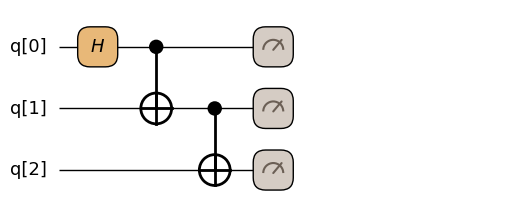

In [4]:
fixed_circuit.draw()

In [5]:
est = fixed_circuit.estimate_resources()
print("qubits:", est.qubits)
assert est.qubits == 3
print("total gates:", est.gates.total)
assert est.gates.total == 3
print("single-qubit gates:", est.gates.single_qubit)
assert est.gates.single_qubit == 1
print("two-qubit gates:", est.gates.two_qubit)
assert est.gates.two_qubit == 2

qubits: 3
total gates: 3
single-qubit gates: 1
two-qubit gates: 2


## シンボリックなリソース推定

量子カーネルに未バインドのパラメータ（例：`n: qmc.UInt`）がある場合、`estimate_resources()`は**SymPy式**を返します。特定の値を選ばなくてもコストのスケーリングが分かります。

In [6]:
@qmc.qkernel
def scalable_circuit(n: qmc.UInt, theta: qmc.Float) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    q = qmc.h(q)
    q = qmc.ry(q, theta)

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])

    return qmc.measure(q)

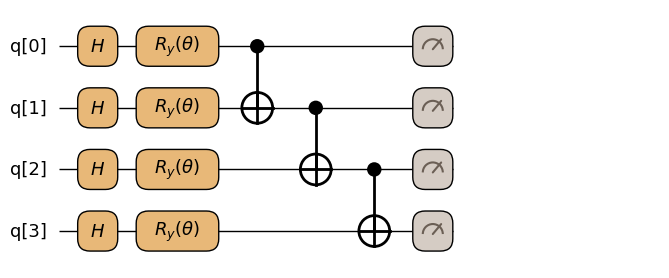

In [7]:
scalable_circuit.draw(n=4, fold_loops=False)

In [8]:
est = scalable_circuit.estimate_resources()
print("qubits:", est.qubits)
assert str(est.qubits) == "n"
print("total gates:", est.gates.total)
assert str(est.gates.total) == "2*n + Max(0, n - 1)"
print("single-qubit gates:", est.gates.single_qubit)
assert str(est.gates.single_qubit) == "2*n"
print("two-qubit gates:", est.gates.two_qubit)
assert str(est.gates.two_qubit) == "Max(0, n - 1)"
print("rotation gates:", est.gates.rotation_gates)
assert str(est.gates.rotation_gates) == "n"
print("parameters:", est.parameters)
assert set(est.parameters.keys()) == {"n"}

qubits: n
total gates: 2*n + Max(0, n - 1)
single-qubit gates: 2*n
two-qubit gates: Max(0, n - 1)
rotation gates: n
parameters: {'n': n}


出力には、量子ビット数を表す`n`や総ゲート数を表す`2*n + Max(0, n - 1)`のようなSymPy式が含まれます。これらは近似ではなく厳密な値です。

`Max(0, ...)`は`qmc.range(n - 1)`のループ回数に由来します。`n`が未束縛のため`n >= 1`を仮定できず、`n = 0`のときに回数が`-1`になってしまわないよう0で下限を取っています。具体的な`n >= 1`を代入すればこのガードは外れるので、後述の合計値はそのまま整数になります。

## `ResourceEstimate`フィールドリファレンス

| フィールド | 説明 |
|-------|------------|
| `est.qubits` | 論理量子ビット数 |
| `est.gates.total` | 総ゲート数 |
| `est.gates.single_qubit` | 単一量子ビットゲート数 |
| `est.gates.two_qubit` | 2量子ビットゲート数 |
| `est.gates.multi_qubit` | 多量子ビットゲート数（3量子ビット以上） |
| `est.gates.t_gates` | Tゲート数 |
| `est.gates.clifford_gates` | Cliffordゲート数 |
| `est.gates.rotation_gates` | 回転ゲート数 |
| `est.gates.oracle_calls` | オラクル呼び出し回数（名前別の辞書） |
| `est.parameters` | シンボル名からSymPyシンボルへの辞書 |

すべてのフィールドはSymPy式です。固定量子カーネルの場合は通常の整数に評価されます。

## `.substitute()`によるスケーリング分析

シンボリック式は*数式*を示してくれますが、特定のサイズでの具体的な数値も確認したい場合`.substitute()`で評価できます：

In [9]:
for n_val in [4, 8, 16, 32]:
    c = est.substitute(n=n_val)
    print(
        f"n={n_val:2d}: {int(c.gates.total):>3} gates total, {int(c.gates.two_qubit):>2} two-qubit"
    )
    assert int(c.gates.total) == 3 * n_val - 1
    assert int(c.gates.two_qubit) == n_val - 1

n= 4:  11 gates total,  3 two-qubit
n= 8:  23 gates total,  7 two-qubit
n=16:  47 gates total, 15 two-qubit
n=32:  95 gates total, 31 two-qubit


## ショアのアルゴリズムを回路本体から推定する

実用的な例として、ショアのアルゴリズムの量子部分である位数探索を調べます。
`qmc.shor_order_finding()`は、底`base`と法`modulus`を受け取り、実行にもリソース推定にも使える1つの量子カーネルを返します。レジスタ幅は`modulus.bit_length()`から決まるため、返されたカーネルに人工的な`n`引数はありません。


In [10]:
order_finding = qmc.shor_order_finding(base=2, modulus=15)
shor_est = order_finding.estimate_resources()

print("logical qubits:", shor_est.qubits)
print("total logical gates:", shor_est.gates.total)
print("estimate quality:", shor_est.quality)

assert shor_est.parameters == {}
assert shor_est.qubits == 21
assert str(shor_est.quality) == "upper_bound"

logical qubits: 21
total logical gates: 13701
estimate quality: upper_bound


この実装は`2*n`量子ビットのcountingレジスタを同時に保持しません。1つのphase qubitを測定・リセットして再利用し、それまでに得たビットで半古典的inverse QFTの位相補正を行います。

固定window幅を`w`とすると、論理量子ビット数は回路本体のallocationから`3*n + w + 7`になります。

| 用途 | 幅 |
|---|---:|
| 再利用するphase qubit | `1` |
| モジュラ値を保持するworkレジスタ | `n` |
| モジュラ乗算のaccumulator | `n` |
| window lookupの出力レジスタ | `n` |
| lookupのaddress | `w` |
| carry、vent、overflow、reduction、domain、enable | `6` |

既定値は`w=2`なので`3*n + 9`です。法15では`n=4`となり、推定結果の21量子ビットと一致します。これは外部のコスト式を`estimate_resources()`へ登録した値ではなく、実行されるqkernel bodyのpeak-live allocationを数えた結果です。

In [11]:
import sympy as sp
from IPython.display import Math, display

symbolic_n, symbolic_w = sp.symbols("n w", integer=True, positive=True)
shor_width_formula = 3 * symbolic_n + symbolic_w + 7
display(Math(rf"N_\mathrm{{qubit}} = {sp.latex(shor_width_formula)}"))
assert shor_width_formula.subs({symbolic_n: 4, symbolic_w: 2}) == shor_est.qubits

<IPython.core.display.Math object>

法15に対するgate内訳も、同じ実行bodyを最後までたどって得られます。

In [12]:
print("single-qubit gates:", shor_est.gates.single_qubit)
print("two-qubit gates:", shor_est.gates.two_qubit)
print("multi-qubit gates:", shor_est.gates.multi_qubit)
print("Toffoli gates:", shor_est.gates.toffoli)

assert shor_est.gates.total == (
    shor_est.gates.single_qubit
    + shor_est.gates.two_qubit
    + shor_est.gates.multi_qubit
)

single-qubit gates: 6421
two-qubit gates: 3024
multi-qubit gates: 4256
Toffoli gates: 2368


`quality`が`upper_bound`なのは、途中測定に基づくclassical feed-forwardの分岐を安全側に数えるためです。また、ここで得られるのはQamomileの論理回路に対する値です。特定デバイスのnative gateへの分解、ルーティング、誤り訂正、magic state生成などは含みません。

### なぜgate数は`O(n^3)`なのか

`qmc.modmul_const()`は、`w`ビットずつsourceを読み、古典的な倍数をlookupしてaccumulatorへ足します。1回のモジュラ乗算には約`n / w`個のwindowがあります。各windowで使うripple-carry加算、定数減算、比較、条件付き復元はいずれも`O(n)`gateです。定数加減算には[Gidneyのcarry-venting adder](https://arxiv.org/abs/2507.23079)を使い、workレジスタをdirty workspaceとして借りるため、別の`n`量子ビットレジスタは増えません。

したがって固定`w`では、モジュラ乗算1回が`O(n^2)`、既定の位数探索で行う`2*n`回のcontrolled multiplicationが`O(n^3)`です。半古典的inverse QFTのfeed-forwardは`O(n^2)`なので、全体のleading orderを変えません。lookupの`2^w`依存まで書けば、おおよそ`O(2^w n^3 / w)`です。

### モジュラ乗算単体も同じbodyから推定する

公開primitiveは`qmc.modmul_const()`です。FTQC算術は具体的な問題インスタンスへspecializeしてから構築するため、ここでも幅4のkernelをそのまま推定します。

In [13]:
@qmc.qkernel
def modular_multiplier() -> qmc.Vector[qmc.Qubit]:
    reg = qmc.qubit_array(4, name="reg")
    return qmc.modmul_const(
        reg,
        multiplier=2,
        modulus=15,
        window_size=2,
    )

In [14]:
window_est = modular_multiplier.estimate_resources()
print("windowed arithmetic qubits:", window_est.qubits)
print("windowed arithmetic gates:", window_est.gates.total)
assert window_est.qubits == 3 * 4 + 2 + 7

windowed arithmetic qubits: 21
windowed arithmetic gates: 1708


standalone版では、無条件実行を表す内部controlがphase qubitの代わりになるため、位数探索全体と同じ`3*n + w + 7`幅になります。`modmul_const()`は`x < modulus`の領域では`|x> -> |a*x mod modulus>`を実行し、領域外の基底状態はunitaryを保つため変更しません。

### Ekerå–Håstadの短い指数スケジュール

`qmc.ekera_hastad_factoring()`は、同程度のビット長を持つ2素数の積を対象とする[Ekerå–Håstad法](https://arxiv.org/abs/1702.00249)のshort discrete logarithm量子段を構築します。Qamomileでは`m = ceil(n / 2) + 1`とし、長さ`2*m`と`m`の位相スケジュールを順番に測定します。

2つの指数レジスタをcoherentに保持するのではなく、同じphase qubitと算術workspaceを再利用します。そのため幅はShorと同じ`3*n + w + 7`で、違いはcontrolled modular multiplicationの回数です。返り値は先頭`2*m`ビットが長いスケジュール、残り`m`ビットが短いスケジュールで、それぞれlittle-endianです。

In [15]:
short_dlp = qmc.ekera_hastad_factoring(
    generator=2,
    modulus=5,
    window_size=2,
)
short_dlp_est = short_dlp.estimate_resources()

print("Ekerå–Håstad logical qubits:", short_dlp_est.qubits)
print("Ekerå–Håstad total logical gates:", short_dlp_est.gates.total)
assert short_dlp_est.qubits == 3 * 3 + 2 + 7
assert len(short_dlp.output_types) == 9

Ekerå–Håstad logical qubits: 18
Ekerå–Håstad total logical gates: 10963


## まとめ

- `estimate_resources()`は実行せずに量子ビット数とゲートコストを算出します。
- パラメータ付き量子カーネルでは、結果はスケーリングを示すSymPy式になります。`quality`で厳密値か上限値かを確認できます。
- `.substitute(n=...)`で特定のサイズに代入し、実行可能性を確認できます。
- FTQC版のShorとEkerå–Håstadは、同じ`O(n^2)`のwindowed modular multiplication bodyと、1つの再利用phase qubitを共有します。
- 固定window幅では、回路本体から得られる幅は`3*n + w + 7`、Shorの既定精度でgate数は`O(n^3)`です。
- 問題インスタンスにspecializeされたFTQC kernelは具体的な推定値を返します。サイズ依存性は、異なる法から作った実body同士を比較して確認します。

**次へ**：[実行モデル](06_execution_models.ipynb) — `sample()`と`run()`、オブザーバブル、ビット順序について。